In [2]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
# from get_ddf import get_hourly_df
from data_handling import *
import statsmodels.api as sm
from scipy.stats import gaussian_kde as kde
import sys 
from scipy.optimize import minimize
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/ddf/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']
coord_dict = {'wolverine':'60.5_-148.8',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.4',
                'lemon_creek':'58.5_-134.4',
                'gulkana':'63.5_-145.6'}
site_dict = {
    'kahiltna':['K17b','K53'], # KAHILTNA     'KPS','K14k',
    'kennicott':['GTH','KC31','GTL'], # KENNICOTT
    'gulkana':['AU','B','D'], # GULKANA
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C','D'], # LEMON CREEK
    'taku':['MG1','NWB1','TKG3'], # TAKU
}

site_dict = {'gulkana':['T','Z'],
             'kahiltna':['KPS', 'KQU'],
             'wolverine':['EC']}
base_fp = '/trace/group/rounce/cvwilson/Output/paper2/'
fn_before = base_fp + '{g}{s}_sensitivity/{g}{s}_2025_10_06_temp+0_0.nc'
fn_after = base_fp + '{g}{s}_sensitivity/{g}{s}_temp+0_fixedgrains_0.nc'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import pickle
params = {'gulkana': {'Z': {'kp': 3.5, 'lapse_rate': -3.5},
                     'T': {'kp': 3.5, 'lapse_rate': -3.5}},
          'kahiltna':{'KPS': {'kp': 1.75, 'lapse_rate': -5.5},
                     'KQU': {'kp': 1, 'lapse_rate': -5.5}},
          'wolverine':{'EC': {'kp': 1.75, 'lapse_rate': -9}}}

with open('/trace/group/rounce/cvwilson/Firn/firn_params_final.pkl', 'wb') as f:
    pickle.dump(params, f)

getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaT_subset/gulkanaT_[kp2.25_,: No such file or directory
getfattr: lapse_rate-3.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaT_subset/gulkanaT_[kp2.75_,: No such file or directory
getfattr: lapse_rate-3.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaT_subset/gulkanaT_[kp2.75_,: No such file or directory
getfattr: lapse_rate-4_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaT_subset/gulkanaT_[kp3.25_,: No such file or directory
getfattr: lapse_rate-3.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaT_subset/gulkanaT_[kp3.25_,: No such file or directory
getfattr: lapse_rate-4_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaT_subset/gulkanaT_[kp3.5_,: No such file or directory
getfattr: lapse_rate

ACTUAL PARAMS MAE 0.3401722310317101


getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaT_subset/gulkanaT_[kp3_,: No such file or directory
getfattr: lapse_rate-3.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaT_subset/gulkanaT_[kp3_,: No such file or directory
getfattr: lapse_rate-4_]_0.nc: No such file or directory


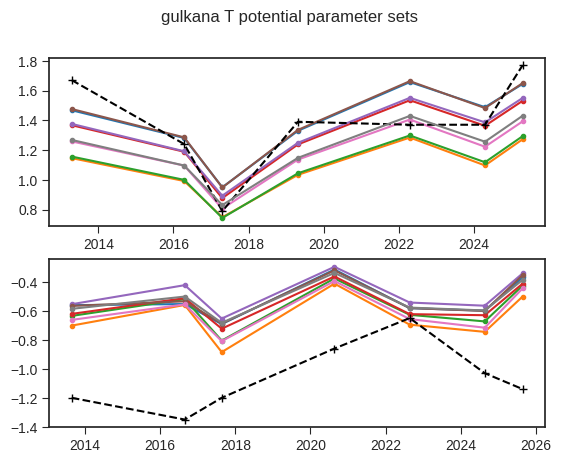

0.37968448393358195 ('2.75', '-4')


getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaZ_subset/gulkanaZ_[kp2.25_,: No such file or directory
getfattr: lapse_rate-3.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaZ_subset/gulkanaZ_[kp2.25_,: No such file or directory
getfattr: lapse_rate-4.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaZ_subset/gulkanaZ_[kp2.25_,: No such file or directory
getfattr: lapse_rate-4_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaZ_subset/gulkanaZ_[kp3.25_,: No such file or directory
getfattr: lapse_rate-3.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaZ_subset/gulkanaZ_[kp3.25_,: No such file or directory
getfattr: lapse_rate-4.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaZ_subset/gulkanaZ_[kp3.25_,: No such file or directory
getfattr: lapse_r

ACTUAL PARAMS MAE 0.6336404607252285


getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaZ_subset/gulkanaZ_[kp3.5_,: No such file or directory
getfattr: lapse_rate-4_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/gulkanaZ_subset/gulkanaZ_[kp3_,: No such file or directory
getfattr: lapse_rate-3.5_]_0.nc: No such file or directory


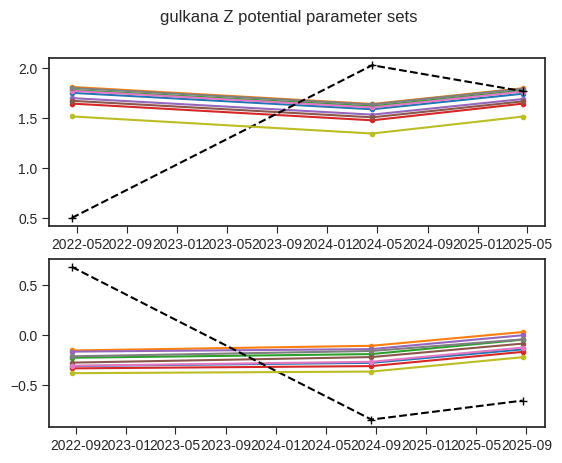

0.6656903078595628 ('2.25', '-4.5')


getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.5_,: No such file or directory
getfattr: lapse_rate-3.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.5_,: No such file or directory
getfattr: lapse_rate-4.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.5_,: No such file or directory
getfattr: lapse_rate-4_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.5_,: No such file or directory
getfattr: lapse_rate-5.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.5_,: No such file or directory
getfattr: lapse_rate-5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.75_,: No such file o

ACTUAL PARAMS MAE 0.9541897925670839


getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.75_,: No such file or directory
getfattr: lapse_rate-5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.75_,: No such file or directory
getfattr: lapse_rate-6.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.75_,: No such file or directory
getfattr: lapse_rate-6_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.75_,: No such file or directory
getfattr: lapse_rate-7.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.75_,: No such file or directory
getfattr: lapse_rate-7_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKPS_subset/kahiltnaKPS_[kp1.75_,: No such fil

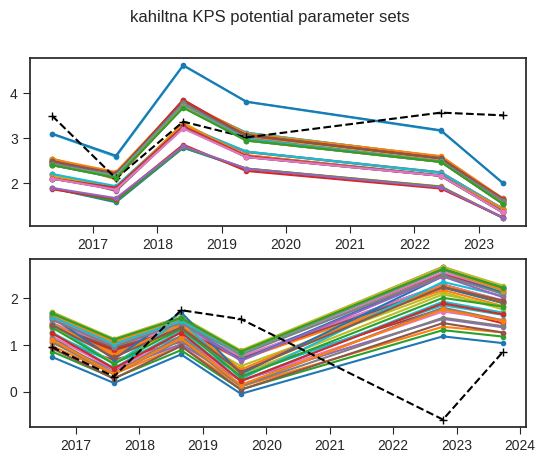

1.0517351760468592 ('1.5', '-5.5')


getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp0.5_,: No such file or directory
getfattr: lapse_rate-3.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp0.5_,: No such file or directory
getfattr: lapse_rate-4.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp0.5_,: No such file or directory
getfattr: lapse_rate-4_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp0.5_,: No such file or directory
getfattr: lapse_rate-5.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp0.5_,: No such file or directory
getfattr: lapse_rate-5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp0.5_,: No such file or

ACTUAL PARAMS MAE 0.3367118403733391


getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp1_,: No such file or directory
getfattr: lapse_rate-5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp1_,: No such file or directory
getfattr: lapse_rate-6.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp1_,: No such file or directory
getfattr: lapse_rate-6_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp1_,: No such file or directory
getfattr: lapse_rate-7.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp1_,: No such file or directory
getfattr: lapse_rate-7_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/kahiltnaKQU_subset/kahiltnaKQU_[kp1_,: No such file or directory
get

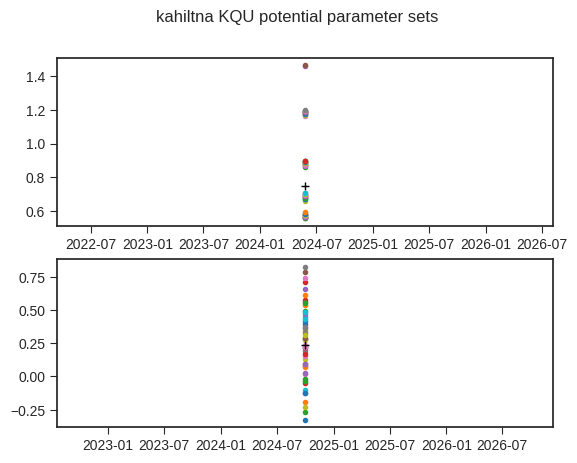

0.518552050550684 ('1.25', '-4')


getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp1.25_,: No such file or directory
getfattr: lapse_rate-7.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp1.25_,: No such file or directory
getfattr: lapse_rate-8.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp1.25_,: No such file or directory
getfattr: lapse_rate-8_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp1.25_,: No such file or directory
getfattr: lapse_rate-9_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp1.5_,: No such file or directory
getfattr: lapse_rate-6.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp1.5_,: No such fil

ACTUAL PARAMS MAE 0.42946249190781877


getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp1_,: No such file or directory
getfattr: lapse_rate-9_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp2.25_,: No such file or directory
getfattr: lapse_rate-5.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp2.25_,: No such file or directory
getfattr: lapse_rate-5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp2.25_,: No such file or directory
getfattr: lapse_rate-6.5_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp2.25_,: No such file or directory
getfattr: lapse_rate-6_]_0.nc: No such file or directory
getfattr: /trace/group/rounce/cvwilson/Output/paper2/wolverineEC_subset/wolverineEC_[kp2.25_,: No such file o

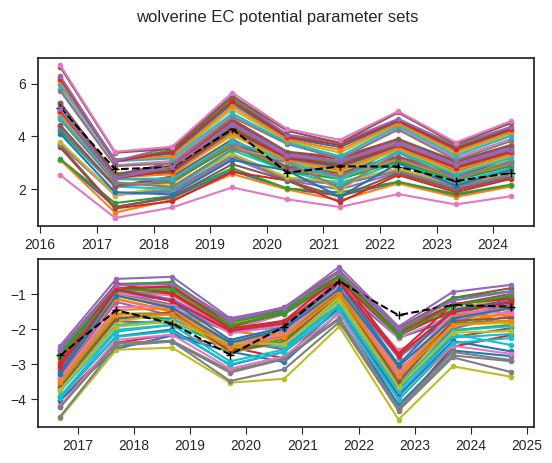

1.0472773417086736 ('2.25', '-5')


In [9]:
g, s = 'gulkana','Z'

for g in site_dict:
    for s in site_dict[g]:
        directory = f'/trace/group/rounce/cvwilson/Output/paper2/{g}{s}_subset/'
        fns = os.listdir(directory)

        # fmt = "{g}{s}_['kp{k}_', 'lapse_rate{l}_']_0.nc"
        # ds = xr.open_dataset(directory + fmt.format(g=g, s=s, k=params[g][s]['kp'], l=params[g][s]['lapse_rate']))
        # mb = MassBalance(g, s, min_n_winter=0)
        # mb.get_model_mb(ds)
        # mb.plot_mb()
        # plt.savefig(f'/trace/group/rounce/cvwilson/Firn/Figs/{g}{s}_seasonalmb.png', dpi=300)

        site_mae = []
        site_params = []
        fig, axes = plt.subplots(2)
        for fn in fns:
            use_fn = os.path.join(directory, fn)
            kp = fn.split('kp')[-1].split('_')[0]
            lapserate = fn.split('lapse_rate')[-1].split('_')[0]
            ds = xr.open_dataset(use_fn)
            if ds.melt.sum() == 0:
                continue

            mb = MassBalance(g, s, min_n_winter=0)
            mb.get_model_mb(ds)
            site_mae.append(mb.mae())
            site_params.append((kp, lapserate))
            best_kp, best_lapserate = str(params[g][s]['kp']), str(params[g][s]['lapse_rate'])
            if kp == best_kp and lapserate == best_lapserate:
                print('ACTUAL PARAMS MAE', mb.mae())

            data = mb.split_winter_summer()

            for i, season in enumerate(['winter','summer']):
                if fn == fns[-1]:
                    axes[i].plot(data['time'][season], data['meas'][season], 'k--', label='Measured', marker='+')

                axes[i].plot(data['time'][season], data['mod'][season], label=f'kp {kp}  lr {lapserate}', marker='.')
        for ax in axes:
            ax.tick_params(length=5)
            # ax.legend()
        fig.suptitle(g + ' ' + s + ' potential parameter sets')
        plt.savefig('/trace/group/rounce/cvwilson/figs/{g}{s}_subset_mb.png')
        plt.show()

        print(np.max(site_mae), site_params[np.argmax(site_mae)])

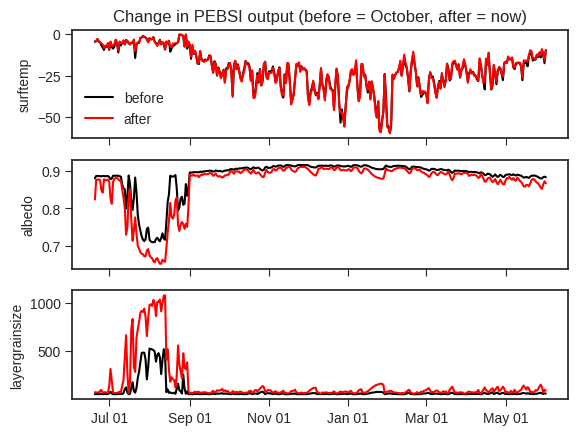

In [3]:

g, s = 'kahiltna','KPS'
fn_before = base_fp + '{g}{s}_sensitivity/{g}{s}_2025_10_06_temp+0_0.nc'
fn_after = base_fp + '{g}{s}_sensitivity/{g}{s}_temp+0_nocap_0.nc'
fig, axes = plt.subplots(3, sharex=True)
for var, ax in zip(['surftemp', 'albedo', 'layergrainsize'], axes): # 'sensible','latent','LWnet','SWnet','rain']:
    values = {}
    colors = ['black','red']
    for string, fn, c in zip(['before','after'], [fn_before, fn_after], colors):
        ds = xr.open_dataset(fn.format(g=g, s=s)).isel(layer=0)
        ds = ds[var].sel(time=slice('2023-06-20','2024-06-01')).resample(time='d').mean()
        ax.plot(ds.time, ds.values, label=string, c=c)
        
    ax.set_ylabel(var)
    ax.tick_params(length=5)
    # values[string] = ds.values

axes[0].legend()
axes[0].set_title('Change in PEBSI output (before = October, after = now)')
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%b %d'))
# ax[1].plot(ds.time, values['after'] - values['before'])
plt.savefig('pebsi_problem.png')
plt.show()

In [ ]:
# u = xr.open_dataarray('/trace/group/rounce/cvwilson/climate_data/MERRA2/58.5_-134.4/U2M_58.5_-134.4.nc')
# v = xr.open_dataarray('/trace/group/rounce/cvwilson/climate_data/MERRA2/58.5_-134.4/U2M_58.5_-134.4.nc')

# df = pd.read_csv('/trace/group/rounce/cvwilson/climate_data/benchmark/lemonCreek/LVL2/lemoncreek1285_hourly_LVL2.csv')

# w = np.sqrt(np.square(u.values) + np.square(v.values))
# bins = np.arange(0, 30, 1)
# plt.hist(w, histtype='step', bins=bins, label='MERRA-2 original', density=True)
# plt.hist(w*2, histtype='step', bins=bins, label='MERRA-2 w/ $k_w=2$', density=True)
# plt.hist(df['WindSpeed'].values, histtype='step', bins=bins, label='AWS (ridge)', density=True)
# plt.legend()
# plt.ylabel('Density')
# plt.xlabel('Wind speed (m/s)')
# plt.title('Wind speed example at Lemon Creek')
# plt.show()

In [2]:
site_dict = {
    'wolverine':['EC'],
    'kahiltna':['KPS','KQU',],
    'gulkana':['T','Z'],
}
out_fn = '../paper2/{g}{s}_sensitivity/{g}{s}_{v}_FINAL_0.nc'
for v in ['temp+0', 'temp+0.5', 'temp+1', 'temp+2', 'tpx1','tpx1.05','tpx1.1','tpx1.2']: # 
    for glacier in site_dict:
        for site in site_dict[glacier]:    
            ds = xr.open_dataset(base_fp + out_fn.format(g=glacier, s=site, v=v))
            assert ds.melt.sum() > 0, 'did not save'
            timeres='1d'
            forcing_fn = f'/trace/group/rounce/cvwilson/Firn/Forcings/{glacier.lower()}{site}/{glacier.lower()}{site}_{timeres}_{v}_forcings_FINAL.csv'

            # get sublimation from any negative vaporsolid mass fluxes in m w.e.
            ds['vaporsolid'][ds['vaporsolid'] > 0] = 0
            ds['sublim'] = ds['vaporsolid']

            # change units of surftemp
            ds['surftemp'] += 273.15

            # resample to the specified resolution with sum (mass balance terms) and mean (surface temp)
            ds_mb = ds[['melt','accum','rainfall','sublim']].resample(time=timeres).sum()
            ds_mb *= 1000   # convert m w.e. to kg m-2
            ds_other = ds[['surftemp']].resample(time=timeres).mean()

            # merge datasets and rename
            data_in = xr.merge([ds_mb, ds_other])
            data_in = data_in.rename_vars({'melt':'SMELT', 'rainfall':'RAIN', 
                                           'surftemp':'TS', 'accum':'BDOT',
                                           'sublim':'SUBLIM'}) # , 'surfdens':'RHOS'

            # store data as a .csv       
            df = data_in[['BDOT','RAIN','TS','SMELT','SUBLIM']].to_dataframe()
            print(forcing_fn, 'stored')
            df.to_csv(forcing_fn)

/trace/group/rounce/cvwilson/Firn/Forcings/wolverineEC/wolverineEC_1d_temp+0_forcings_FINAL.csv stored
/trace/group/rounce/cvwilson/Firn/Forcings/kahiltnaKPS/kahiltnaKPS_1d_temp+0_forcings_FINAL.csv stored
/trace/group/rounce/cvwilson/Firn/Forcings/kahiltnaKQU/kahiltnaKQU_1d_temp+0_forcings_FINAL.csv stored
/trace/group/rounce/cvwilson/Firn/Forcings/gulkanaT/gulkanaT_1d_temp+0_forcings_FINAL.csv stored
/trace/group/rounce/cvwilson/Firn/Forcings/gulkanaZ/gulkanaZ_1d_temp+0_forcings_FINAL.csv stored
/trace/group/rounce/cvwilson/Firn/Forcings/wolverineEC/wolverineEC_1d_temp+0.5_forcings_FINAL.csv stored
/trace/group/rounce/cvwilson/Firn/Forcings/kahiltnaKPS/kahiltnaKPS_1d_temp+0.5_forcings_FINAL.csv stored
/trace/group/rounce/cvwilson/Firn/Forcings/kahiltnaKQU/kahiltnaKQU_1d_temp+0.5_forcings_FINAL.csv stored
/trace/group/rounce/cvwilson/Firn/Forcings/gulkanaT/gulkanaT_1d_temp+0.5_forcings_FINAL.csv stored
/trace/group/rounce/cvwilson/Firn/Forcings/gulkanaZ/gulkanaZ_1d_temp+0.5_forcings_F

In [27]:
site_df = pd.read_csv('../data/by_glacier/kennicott/site_constants.csv', index_col=0)

for point in points:
    elev = 'K'+str(int(point['elevation']))
    site_df.loc[elev] = [np.nan] * len(site_df.columns)
    site_df.loc[elev, 'lat'] = point['lat']
    site_df.loc[elev, 'lon'] = point['lon']
    site_df.loc[elev, 'elevation'] = point['elevation']
site_df.to_csv('../data/by_glacier/kennicott/site_constants.csv')

In [ ]:
glacier = 'gulkana'
site = 'B'
snowmelt_class = SnowMelt(glacier, site)
dem_class = DEM(glacier)
albedo = Albedo(glacier, site)
dem_class.reproject_to(albedo.ds)
albedo.plot_map_snowline('2021-07-01', snowmelt_class, dem_class, snowline_var='snowline_elev_m', plot_sites=[site])

In [ ]:
# FORCE THE MODEL USING REMOTELY SENSED ALBEDO
# for glacier in site_dict:
#     for site in site_dict[glacier]:
#         albedo = Albedo(glacier, site)
#         if len(np.where(~np.isnan(albedo.data))[0]) < 10:
#             continue

#         df_all = None
#         for year in np.unique(pd.to_datetime(albedo.time).year):
#             idx_year = np.where(pd.to_datetime(albedo.time).year == year)[0]
#             df = pd.DataFrame({'albedo': albedo.data.flatten()[idx_year]}, 
#                           index=pd.to_datetime(albedo.time)[idx_year])
#             df.index = pd.to_datetime(df.index).normalize()
#             df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='D'))
#             df = df.interpolate(method='time')

#             df.index = pd.DatetimeIndex(df.index)
            
#             df.loc[df.index.min() - pd.Timedelta(days=1),'albedo'] = 0.85
#             df.loc[df.index.max() + pd.Timedelta(days=1),'albedo'] = 0.85
#             df = df.sort_index()

#             if df_all is None:
#                 df_all = df 
#             else:
#                 df_all = pd.concat([df_all, df])

#         df_all = df_all.reindex(pd.date_range(df_all.index[0], df_all.index[-1]))
#         df_all = df_all.interpolate(method='time')
#         df_hourly = df.resample('h').ffill().sort_index()
#         plt.plot(df_all.index, df_all['albedo'])
#         # print(df_all)
#         df_all.to_csv(home_fp + f'climate_data/AWS/albedo/{glacier}{site}_S2albedo.csv')
#         # assert 1==0

wolverine EC 2.099132202834925


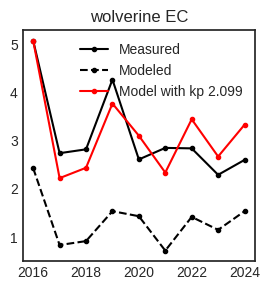

kahiltna KPS 2.0376770367553396


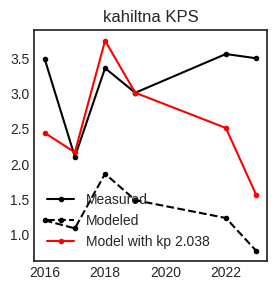

kahiltna KQU 0.5919060765797338


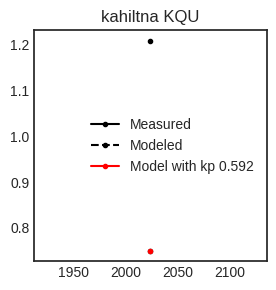

gulkana T 3.4845807547976015


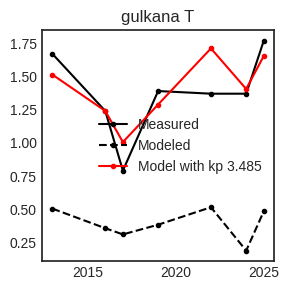

gulkana Z 3.4592243649891796


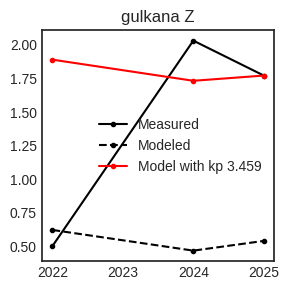

In [ ]:
# FIND KP

# def find_kp(k, ds, bmeas, starts, ends):
#     acc_mod = []
#     add_mod = []
#     for start, end in zip(starts, ends):
#         acc_mod.append(ds.sel(time=slice(start, end)).accum.sum().values)
#         refreeze = ds.sel(time=slice(start, end)).refreeze.sum().values
#         melt = -1*ds.sel(time=slice(start, end)).melt.sum().values
#         add_mod.append(refreeze + melt)
#     acc_mod = np.array(acc_mod)
#     add_mod = np.array(add_mod)
    
#     objective = np.mean(np.abs((acc_mod * k + add_mod) - np.array(bmeas)))
#     return objective

# all_albedo = {'mod':[], 'meas':[]}
# for glacier in site_dict:
#     site_fn = f'../data/by_glacier/{glacier}/site_constants.csv'
#     site_df = pd.read_csv(site_fn, index_col=0)
#     if 'kp' not in site_df.columns:
#         site_df['kp'] = site_df['lat'].copy() * np.nan

#     for site in site_dict[glacier]:
#         mb = MassBalance(glacier, site, use='benchmark', min_n_winter=0)
#         ds = xr.open_dataset(f'/trace/group/rounce/cvwilson/Output/paper2/recalibrate_{site}grid_{glacier}_{site}_kp1_windfactor1_0.nc') # base_fp + f'{glacier}{site}_2026_02_26_base_0.nc')

#         # mb.get_model_mb(ds)
#         # mb.plot_mb()
#         # albedo = Albedo(glacier, site)
#         # albedo.get_model_albedo(ds)
#         # albedo.plot_timeseries()
#         # for mod, meas in zip(albedo.mod, albedo.meas):
#         #     all_albedo['mod'].append(mod)
#         #     all_albedo['meas'].append(meas)

#         if mb.dataset == 'seasonal':
#             mb.get_model_mb(ds)
#             starts = mb.period_starts[mb.idx_winter]
#             ends = mb.period_ends[mb.idx_winter]
#             bw_meas = mb.meas[mb.idx_winter]
            
#             result = minimize(find_kp,1,
#                                       method='L-BFGS-B',bounds=((0, 5),),
#                                       args=(ds, bw_meas, starts, ends))
#             kp = result.x[0]
#             site_df.loc[site, 'kp'] = kp

#             bw_mod = []
#             bw_mod_kp = []
#             for start, end in zip(starts, ends):
#                 acc = ds.sel(time=slice(start, end)).accum.sum().values
#                 refreeze = ds.sel(time=slice(start, end)).refreeze.sum().values
#                 melt = -1*ds.sel(time=slice(start, end)).melt.sum().values
#                 bw_mod.append(acc + refreeze + melt)
#                 bw_mod_kp.append(acc*kp + refreeze + melt)

#             print(glacier, site, kp)
#             plt.figure(figsize=(3,3))
#             plt.plot(pd.to_datetime(ends).year, bw_meas, 'k', label='Measured', marker='.')
#             plt.plot(pd.to_datetime(ends).year, bw_mod, 'k--', label='Modeled', marker='.')
#             plt.plot(pd.to_datetime(ends).year, bw_mod_kp, 'r', label=f'Model with kp {kp:.3f}', marker='.')
#             plt.title(glacier+' '+site)
#             plt.legend()
#             plt.show()
#     site_df.to_csv(site_fn)

In [16]:
xr.open_dataset('/trace/group/rounce/cvwilson/climate_data/GCMs/bias_corrected/ACCESS-ESM1-5/ACCESS-ESM1-5_ssp126_r1i1p1f1_pr_era5corrected.nc')

/trace/home/cvwilson/miniconda3/envs/pebsi_env/lib/python3.13/site-packages/xarray/coding/times.py:1005: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/trace/home/cvwilson/miniconda3/envs/pebsi_env/lib/python3.13/site-packages/xarray/core/indexing.py:514: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(self.get_duck_array(), dtype=dtype, copy=copy)


<xarray.Dataset> Size: 22GB
Dimensions:  (lat: 721, lon: 1440, time: 5412)
Coordinates:
  * time     (time) object 43kB 1850-01-16 12:00:00 ... 2300-12-16 12:00:00
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
Data variables:
    pr       (lat, lon, time) float32 22GB ...
Attributes: (12/49)
    CDI:                    Climate Data Interface version 2.0.6 (https://mpi...
    source:                 ACCESS-ESM1.5 (2019): \naerosol: CLASSIC (v1.0)\n...
    institution:            Commonwealth Scientific and Industrial Research O...
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    version:                v20191115
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/e1bc1d0d-54d8-4a7f-adae-d3f6324a2366
    license:                CMIP6 model data produced by CSIRO is licensed un...
    CDO:                    Climate Data Operators version 2.0.6 (https://mpi...
    units:                  kg m-2 s-1

In [38]:
acc_sites = []
for glacier in site_dict:
    for site in site_dict[glacier]:
        data = MassBalance(glacier, site, use='benchmark annual')
        if np.mean(data.data) > 0:
            acc_sites.append(glacier+site)

In [ ]:
glacier = 'gulkana'
site = 'B'
data = SnowMelt(glacier, site)
ds = xr.open_dataset(base_fp + f'{glacier}{site}_2026_02_03_base_long_0.nc')
data.get_model_snow(ds)
error = data.model_error_metric(data.mod_melt, data.sar_melt['med'], data.time, transition_type='onset')
print('Melt onset MAE:',error,'days')

error = data.model_error_metric(data.mod_snow, data.sar_snow['med'], data.time, transition_type='offset')
print('Snowline MAE:',error,'days')

In [ ]:
data.plot_snow_bool()
data.plot_melt_bool()

In [ ]:
#comparing quantile mapping approaches
# ds_lemon = xr.open_dataset(base_fp + 'takuTKG3_2026_02_15_base_qmlemonkp2_0.nc')
# ds_gulk = xr.open_dataset(base_fp + 'takuTKG3_2026_02_12_base_qmallkp2_0.nc')

coords = '58.5_-134.3'
for var in ['wind','temp','rh']:
    if var == 'wind':
        dsu = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/U2M_{coords}.nc')['U2M']
        dsv = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/V2M_{coords}.nc')['V2M']
        ds_clim = np.sqrt(np.square(dsu.values) + np.square(dsv.values))
    elif var == 'rh':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/RH2M_{coords}.nc')['RH2M'].values
    elif var == 'temp':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/T2M_{coords}.nc')['T2M'].values - 273.15
    varn = var if var != 'temp' else 'temp_0'
    df_gulk = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_gulkana_{varn}.csv')
    df_lem = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_lemon_creek_{varn}.csv')
        
    # interpolate values according to quantile mapping
    values = ds_clim
    adj_gulk = np.interp(values, df_gulk['sorted'], df_gulk['mapping'])
    adj_lem = np.interp(values, df_lem['sorted'], df_lem['mapping'])

    # plt.scatter(adj_gulk, adj_lem, s=5, alpha=0.5)
    plt.scatter(values, adj_lem, s=5, alpha=0.5,label='lemon')
    plt.scatter(values, adj_gulk, s=5, alpha=0.5,label='gulkana')
    minn = np.min([adj_gulk, adj_lem])
    maxx = np.max([adj_gulk, adj_lem])
    plt.ylabel('Original MERRA-2') # Lemon Creek adjusted')
    plt.xlabel('Adjusted') # Gulkana adjusted')
    plt.plot([minn,maxx],[minn,maxx],'k--')
    plt.legend()
    plt.title(var)
    plt.show()

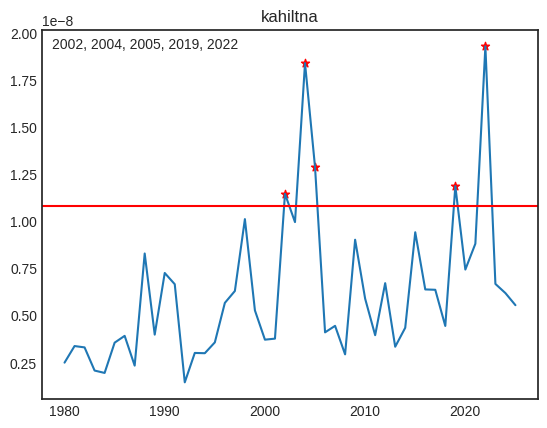

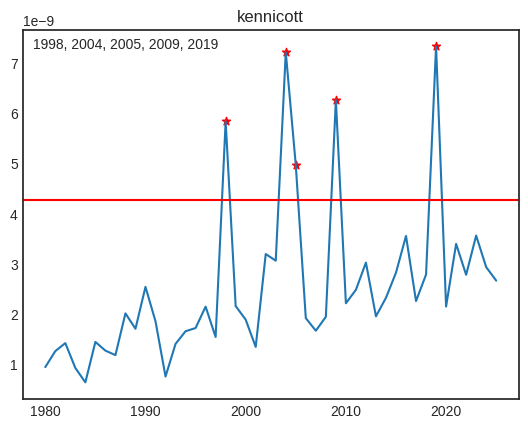

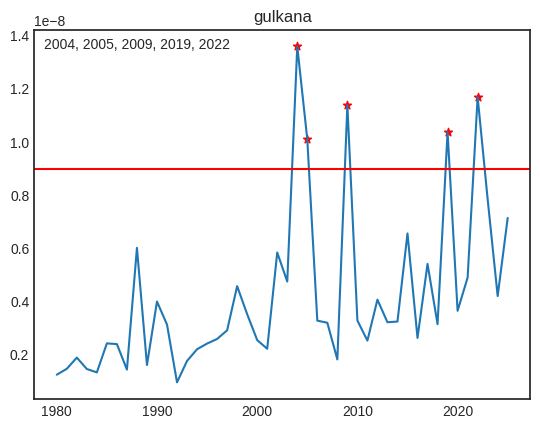

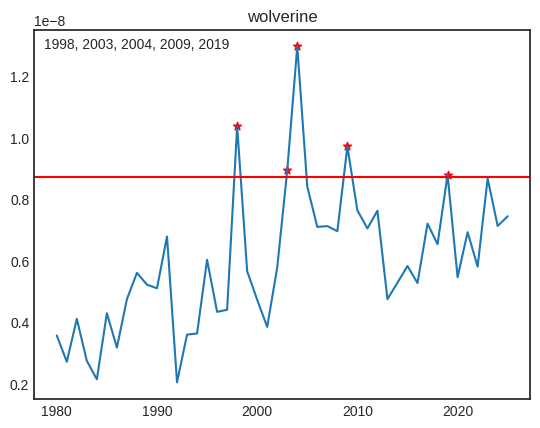

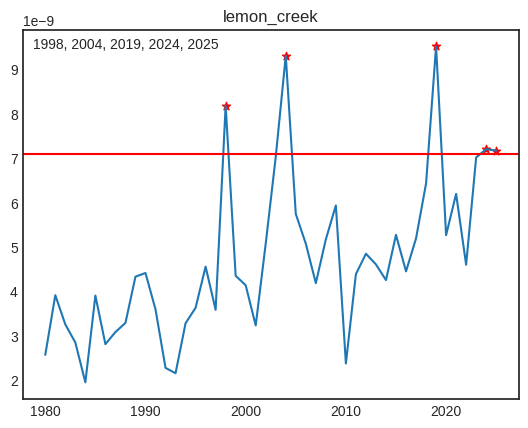

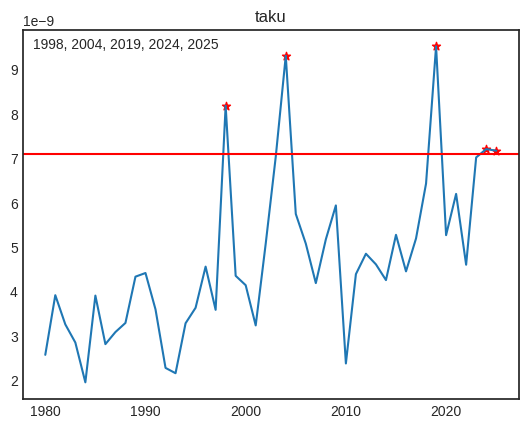

In [61]:
for glacier in site_dict:
    coords = coord_dict[glacier]
    ds = xr.open_dataset(base_fp + f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds2 = xr.open_dataset(base_fp + f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds['BCDP002'] = ds['BCDP002'] + ds2['BCWT002']
    # define time variables
    months = ds['time'].dt.month
    days = ds['time'].dt.day
    # create time mask from apr 1 to sep 30 (inclusive)
    mask = ((months > 3) & (months < 10))
    ds_season = ds.where(mask, drop=True)
    annual_sums = ds_season.groupby('time.year').sum()
    fig, ax = plt.subplots()
    ax.plot(annual_sums.year, annual_sums['BCDP002'].values)
    ax.axhline(np.quantile(annual_sums['BCDP002'].values, 0.90), c='r')

    threshold = np.quantile(annual_sums['BCDP002'].values, 0.90)
    base_idx = np.where(annual_sums['BCDP002'].values <= threshold)[0]
    fire_idx = np.where(annual_sums['BCDP002'].values > threshold)[0]

    fire_years = annual_sums.year.values[fire_idx]
    base_years = annual_sums.year.values[base_idx]

    ax.set_title(glacier)
    ax.scatter(annual_sums.year.values[fire_idx], annual_sums['BCDP002'].values[fire_idx], color='red', marker='*')
    ax.text(0.02, 0.95, ', '.join(fire_years.astype(str)), transform=ax.transAxes)
    plt.show()